### 📚 Lesson 4.2: Softmax – Khi output có nhiều class

---

**Mày đã học gì rồi?**

* 4.1: ReLU → best choice cho hidden layers, giúp tránh vanishing gradient, nhưng đôi khi cần thêm neurons vì nó kém “mềm dẻo” hơn tanh.
* Trước đó mày cũng đã biết Sigmoid (cho binary classification).

---

#### ❓ Today's question

“Nếu output có nhiều class (ví dụ phân loại ảnh mèo, chó, gà) thì dùng activation nào cho output layer?”

---

#### 💡 Key ideas

* Với multi-class classification, output phải biểu diễn **phân phối xác suất** trên các class.
* Activation dùng: **Softmax**.

Công thức:

$$
\sigma(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

Tính chất:

* Output luôn ∈ (0,1).
* Tổng các output = 1 → có thể coi như xác suất trên class.
* Kết hợp loss function = **Cross-Entropy Loss** để train ổn định.

👉 Ví dụ: phân loại 3 class: output ≈ \[0.1, 0.7, 0.2] → model dự đoán class 2.

---

#### 📝 Practice Problems

1. **Knowledge check:**

   * Softmax khác Sigmoid ở điểm nào? (về output range và số class hỗ trợ)

2. **Coding (PyTorch):**
   Viết 1 model PyTorch phân loại dữ liệu toy với 3 class:

   * Input = 2D points
   * Label = 0,1,2
   * Network: `Linear(2→16) + ReLU + Linear(16→3) + Softmax`
   * Loss = `nn.CrossEntropyLoss()` (PyTorch tự gộp Softmax trong loss, nên có thể bỏ Softmax layer).
   * Train khoảng 2000 epochs, in loss cuối và một số prediction để xem model có học được không.

---

#### 🧩 Solution


**Question 1:**

- sigmoid -> binary (single value between 0 and 1)
- softmax -> multi-class (probability vector, sum=1). best used with cross-entropy loss.

**Question 2:**

In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.datasets import make_classification

In [2]:
# Data
X, Y = make_classification(
    n_samples=300,
    random_state=42,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
)
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

In [3]:
# Training params
lr = 0.05
epochs = 5000

In [4]:
# Model: 2-layer NN
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 3))

In [5]:
# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

In [ ]:
# Training
loss_records = []
for epoch in tqdm(range(epochs)):
    y_pred = model(X)
    loss = criterion(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_records.append(loss.item())

100%|██████████| 5000/5000 [00:01<00:00, 4758.01it/s]


In [7]:
print(f"Final loss: {loss_records[-1]:.4f}")

Final loss: 0.1110


---

#### 🚀 Bonus

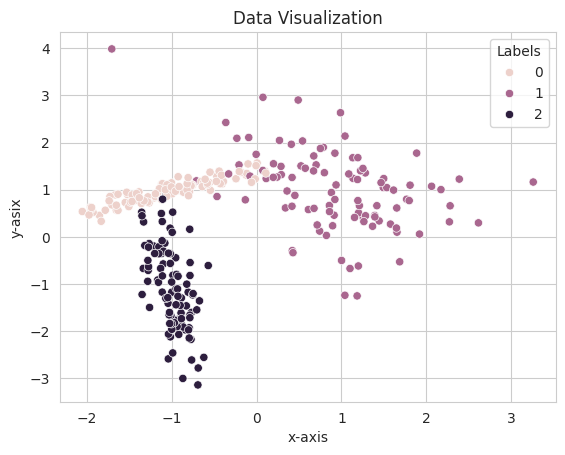

In [8]:
sns.set_style("whitegrid")
sns.scatterplot(x=X.T[0], y=X.T[1], hue=Y)
plt.legend(title="Labels")
plt.xlabel("x-axis")
plt.ylabel("y-asix")
plt.title("Data Visualization")
plt.show()

In [9]:
n = 5
print(f"Testing with {n} random points:")
for i in random.sample(range(300), n):
    y_pred = torch.softmax(model(X[i]), dim=0)
    print(
        f"X = {str(X[i].numpy().round(2)):<13}"
        "  -  "
        f"y_true = {int(Y[i])}"
        "  -  "
        f"prob = {y_pred[Y[i]]:.3f}"
    )

Testing with 5 random points:
X = [-1.39  0.95]  -  y_true = 0  -  prob = 0.988
X = [-1.27 -0.14]  -  y_true = 2  -  prob = 0.999
X = [0.92 0.79]    -  y_true = 1  -  prob = 1.000
X = [-1.11 -1.17]  -  y_true = 2  -  prob = 1.000
X = [-1.42  0.92]  -  y_true = 0  -  prob = 0.987


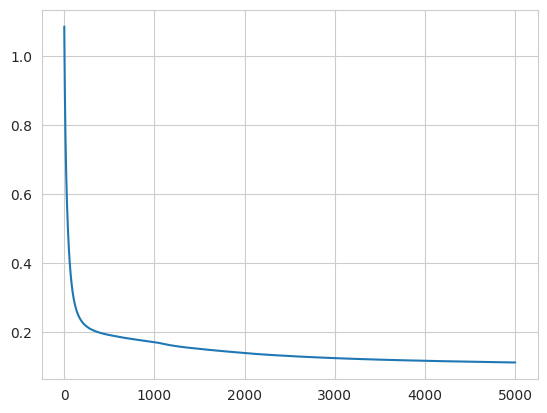

In [10]:
sns.set_style("whitegrid")
sns.lineplot(x=range(epochs), y=loss_records)
plt.show()